# **길이와 무게에 따른 생선 종류 판별하기**

## **1. 데이터 수집**  

*   라이브러리 가져오기
*   데이터 가져오기



In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [5]:
from google.colab import files
files.upload()

Saving Fish.csv to Fish.csv


{'Fish.csv': b'Species,Weight,Length1,Length2,Length3,Height,Width\r\nBream,242,23.2,25.4,30,11.52,4.02\r\nBream,290,24,26.3,31.2,12.48,4.3056\r\nBream,340,23.9,26.5,31.1,12.3778,4.6961\r\nBream,363,26.3,29,33.5,12.73,4.4555\r\nBream,430,26.5,29,34,12.444,5.134\r\nBream,450,26.8,29.7,34.7,13.6024,4.9274\r\nBream,500,26.8,29.7,34.5,14.1795,5.2785\r\nBream,390,27.6,30,35,12.67,4.69\r\nBream,450,27.6,30,35.1,14.0049,4.8438\r\nBream,500,28.5,30.7,36.2,14.2266,4.9594\r\nBream,475,28.4,31,36.2,14.2628,5.1042\r\nBream,500,28.7,31,36.2,14.3714,4.8146\r\nBream,500,29.1,31.5,36.4,13.7592,4.368\r\nBream,340,29.5,32,37.3,13.9129,5.0728\r\nBream,600,29.4,32,37.2,14.9544,5.1708\r\nBream,600,29.4,32,37.2,15.438,5.58\r\nBream,700,30.4,33,38.3,14.8604,5.2854\r\nBream,700,30.4,33,38.5,14.938,5.1975\r\nBream,610,30.9,33.5,38.6,15.633,5.1338\r\nBream,650,31,33.5,38.7,14.4738,5.7276\r\nBream,575,31.3,34,39.5,15.1285,5.5695\r\nBream,685,31.4,34,39.2,15.9936,5.3704\r\nBream,620,31.5,34.5,39.7,15.5227,5.2801\

In [6]:
df=pd.read_csv('Fish.csv', encoding='cp949')

In [7]:
df.columns

Index(['Species', 'Weight', 'Length1', 'Length2', 'Length3', 'Height',
       'Width'],
      dtype='object')

## **2. 데이터 가공**  

*   학습용 데이터 추출  
*   데이터 분할


In [21]:
mask=df['Species'].isin(['Bream','Smelt'])

In [22]:
fish_x=df.loc[mask,['Length1','Weight']]
fish_y=df.loc[mask,'Species']

* <font color='blue'>scikit-learn의 train_test_split 가져오기</font>

In [26]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(fish_x, fish_y, random_state=42)

* 분할된 데이터 확인

In [27]:
print(f"훈련용 학습 데이터의 모양은 {X_train.shape}")
print(f"테스트용 학습 데이터의 모양은 {X_test.shape}")
print(f"훈련용 타켓 데이터의 모양은 {y_train.shape}")
print(f"테스트용 타켓 데이터의 모양은 {y_test.shape}")

훈련용 학습 데이터의 모양은 (36, 2)
테스트용 학습 데이터의 모양은 (13, 2)
훈련용 타켓 데이터의 모양은 (36,)
테스트용 타켓 데이터의 모양은 (13,)


In [28]:
#y_test 확인 결과 bream과 smelt 비율이 맞지 않음
print(y_test)

13     Bream
155    Smelt
157    Smelt
154    Smelt
17     Bream
27     Bream
26     Bream
25     Bream
31     Bream
19     Bream
12     Bream
4      Bream
34     Bream
Name: Species, dtype: object


In [30]:
#비율 맞춰 분할
X_train, X_test, y_train, y_test=train_test_split(fish_x, fish_y, stratify=fish_y, random_state=42)
print(f"훈련용 학습 데이터의 모양은 {X_train.shape}")
print(f"테스트용 학습 데이터의 모양은 {X_test.shape}")
print(f"훈련용 타켓 데이터의 모양은 {y_train.shape}")
print(f"테스트용 타켓 데이터의 모양은 {y_test.shape}")

훈련용 학습 데이터의 모양은 (36, 2)
테스트용 학습 데이터의 모양은 (13, 2)
훈련용 타켓 데이터의 모양은 (36,)
테스트용 타켓 데이터의 모양은 (13,)


In [31]:
print(y_test)

25     Bream
22     Bream
34     Bream
158    Smelt
156    Smelt
18     Bream
151    Smelt
20     Bream
147    Smelt
28     Bream
7      Bream
14     Bream
6      Bream
Name: Species, dtype: object


# **3. 인공지능 모델 학습**  
### <font color='red'>KNN 알고리즘</font>
* knn은 지도학습이지만 훈련되는 것이 없다. **단순히 데이터를 가지고 있는 것이 전부**  
* 새로운 데이터가 입력되면 주변 데이터와의 거리 계산(manhattan 1, Unclidean 2)으로 분류하기 때문

In [32]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()

In [33]:
#모델 학습 및 평가
knn.fit(fish_x,fish_y)
print(knn.score(fish_x,fish_y))

1.0


In [38]:
#실제 데이터 [25,150] 판별
knn.predict([[25,150]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array(['Smelt'], dtype=object)

# <font color='red'>**[문제 발생]**</font>  
정확도가 100%였지만, 실제 데이터인 [25,150]으로 테스트 결과 bream을 smelt로 판별

&nbsp;&nbsp;&nbsp;&nbsp;① [25,150]의 이웃까지 거리 확인  
&nbsp;&nbsp;&nbsp;&nbsp;② 항목 추가




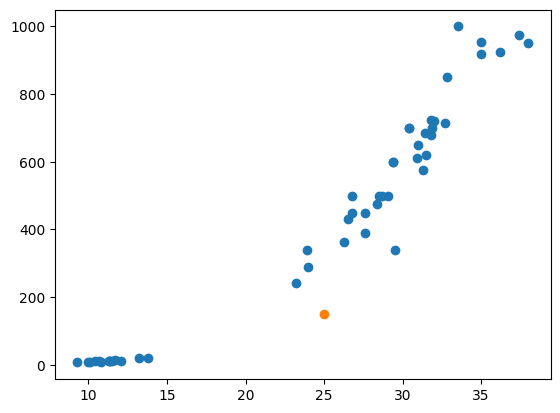

In [39]:
#데이터 시각화를 통한 확인
plt.scatter(fish_x['Length1'],fish_x['Weight'])
plt.scatter(25,150)
plt.show()

In [42]:
dis,indexes=knn.kneighbors([[25,150]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


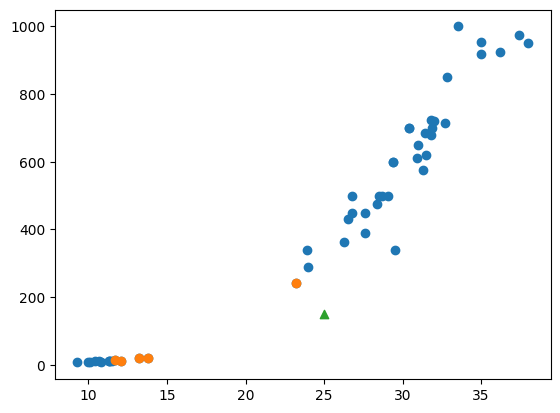

In [45]:
#이웃 데이터 시각화를 통한 확인
plt.scatter(fish_x['Length1'],fish_x['Weight'])
plt.scatter(fish_x.iloc[indexes[0]]['Length1'],fish_x.iloc[indexes[0]]['Weight'])
plt.scatter(25,150,marker='^')
plt.show()

*   **그래프 상 축 범위 통일**  
각 축의 범위 통일 #xlim #ylim   

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<font color='red'>x축의 영향을 거의 받지 않음</font>을 알 수 있음




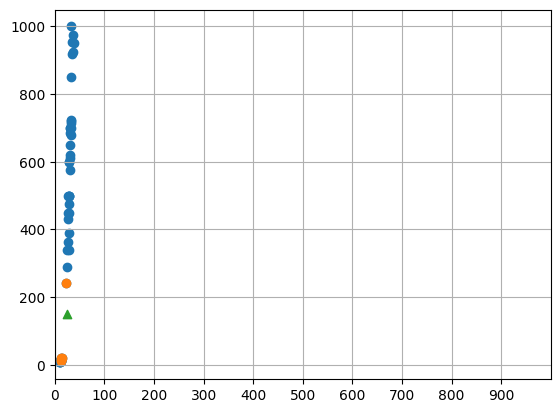

In [52]:
#x축 범위 변환 후 확인
plt.scatter(fish_x['Length1'],fish_x['Weight'])
plt.scatter(fish_x.iloc[indexes[0]]['Length1'],fish_x.iloc[indexes[0]]['Weight'])
plt.scatter(25,150,marker='^')
plt.xlim(0,1000)
plt.xticks(np.arange(0,1000,100))
plt.grid()
plt.show()



*   <font color='red'>**데이터 전처리**</font>  
데이터의 특성값을 일정한 기준으로 맞추는 작업  

&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<font color='green'>표준화?</font> 각 특성값이 0에서 표준편차의 몇 배만큼 떨어져 있는지를 나타냄  
&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;<font color='green'>정규화?</font> 데이터를 특정 범위(보통 0~1)로 나타냄

In [54]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()

In [60]:
ss.fit(X_train)
X_train_s=ss.transform(X_train)
X_test_s=ss.transform(X_test)

In [68]:
knn_s=KNeighborsClassifier()
knn_s.fit(X_train_s,y_train)

KNeighborsClassifier()

In [70]:
knn_s.score(X_train_s,y_train)

1.0

In [71]:
new=[[25,150]]
new_s=ss.transform(new)
knn_s.predict(new_s)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array(['Bream'], dtype=object)

* 시각화 통한 최종 확인

In [80]:
X_train_s

array([[ 0.79962404,  0.85382543],
       [ 0.17119488, -0.24256812],
       [-1.53769142, -1.33066961],
       [ 0.41374649,  0.17817675],
       [-1.5487165 , -1.32729137],
       [ 1.13037623,  1.46805151],
       [-1.48256606, -1.32698425],
       [ 0.51297214,  0.48528979],
       [-1.47154099, -1.32729137],
       [ 0.87679955,  0.83539865],
       [ 0.62322287,  0.79240283],
       [-0.17058238, -0.61417489],
       [ 0.96500013,  1.71374194],
       [-1.43846577, -1.3162353 ],
       [-1.70306752, -1.33681187],
       [-0.0823818 , -0.46676063],
       [ 0.77757389,  0.73098022],
       [ 0.43579663,  0.17817675],
       [-1.58179171, -1.32759848],
       [ 0.22632025,  0.02462023],
       [-1.27308967, -1.29688718],
       [ 0.78859897,  0.79240283],
       [-1.46051591, -1.31992065],
       [ 0.47989692,  0.17817675],
       [ 1.39497798,  1.63696368],
       [ 0.68937331,  0.63884631],
       [ 0.62322287,  0.79240283],
       [-1.62589201, -1.33435497],
       [-0.09340687,

In [84]:
dis,indexes=knn_s.kneighbors(new_s)

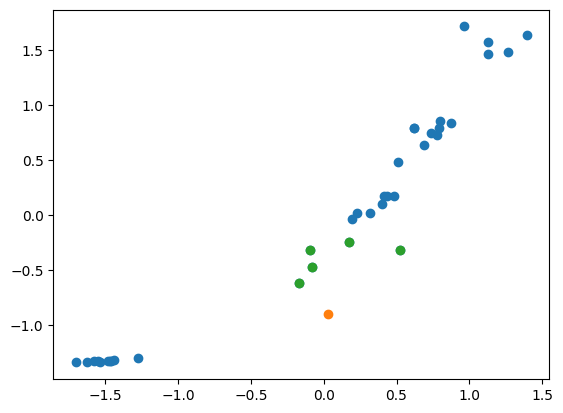

In [85]:
#이웃 데이터 시각화를 통한 확인
plt.scatter(X_train_s[:,0], X_train_s[:,1])
plt.scatter(new_s[:,0],new_s[:,1])
plt.scatter(X_train_s[indexes[0],0],X_train_s[indexes[0],1])
plt.show()